In [1]:
from __future__ import annotations
import numpy as np
import random
import copy
import importlib
import pickle

from typing import Tuple, List
from numpy import array, zeros
from matplotlib import pyplot as plt
from sklearn.preprocessing import normalize

# from Big_Class import Big_Class  # already imported one NETfuncs is imported
from User_Variables import User_Variables  # already imported one NETfuncs is imported
from Network_Structure import Network_Structure  # already imported one NETfuncs is imported
from Big_Class import Big_Class
from Network_State import Network_State
from Networkx_Net import Networkx_Net
from Color_Scheme import Color_Scheme
import matrix_functions, functions, statistics, plot_functions, figure_plots, colors

## colors

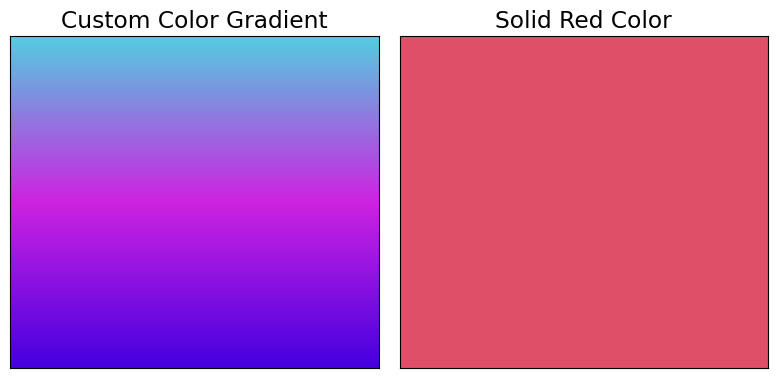

In [2]:
importlib.reload(colors)

colors_lst, red, cmap = colors.color_scheme()
cmap

Colorscheme = Color_Scheme(show=True)

# Figure for "Harnessing common local evolution rules for physical learning"

## 2 Network examples

In [3]:
# load_folder_prelim = 'C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2024.9/inner_variables_2examples/'
# # load_folder_prelim = 'C:/Users/roiee/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2024.9/inner_variables_2examples/'

load_folder_prelim = 'C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2025.3/regression_2_networks/'

t = np.load(load_folder_prelim + 't.npy')
M = np.load(load_folder_prelim + 'M.npy')

input_update_1in2out = np.load(load_folder_prelim + 'input_dual_1in2out.npy')
output_update_1in2out = np.load(load_folder_prelim + 'output_dual_1in2out.npy')
R_1in2out = np.load(load_folder_prelim + 'R_1in2out.npy')
loss_1in2out = np.load(load_folder_prelim + 'loss_1in2out.npy')

input_update_2in1out = np.load(load_folder_prelim + 'input_dual_2in1out.npy')
output_update_2in1out = np.load(load_folder_prelim + 'output_dual_2in1out.npy')
R_2in1out = np.load(load_folder_prelim + 'R_2in1out.npy')
loss_2in1out = np.load(load_folder_prelim + 'loss_2in1out.npy')
with open(load_folder_prelim + 'NETgraph_1in2out.pkl', 'rb') as f:
    NET_1in2out = pickle.load(f)
    
with open(load_folder_prelim + 'pos_lattice_1in2out.pkl', 'rb') as f:
    pos_lattice_1in2out = pickle.load(f)
    
with open(load_folder_prelim + 'NETgraph_2in1out.pkl', 'rb') as f:
    NET_2in1out = pickle.load(f)
    
with open(load_folder_prelim + 'pos_lattice_2in1out.pkl', 'rb') as f:
    pos_lattice_2in1out = pickle.load(f)    

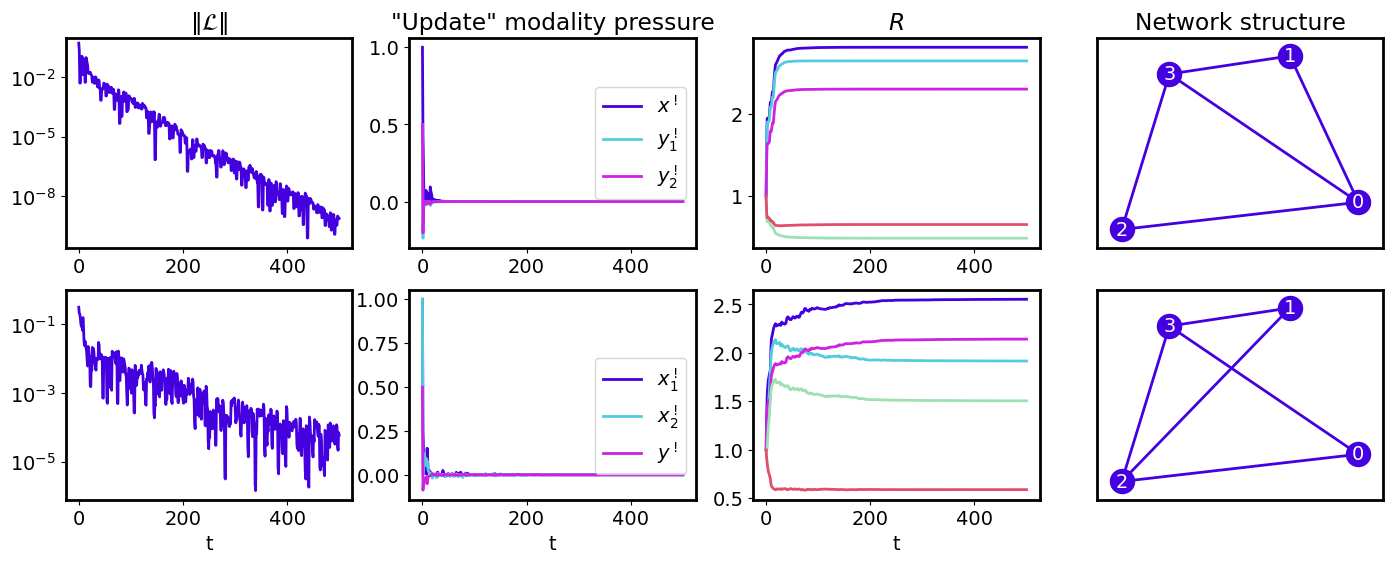

In [4]:
# Reload the module to reflect any changes made
importlib.reload(figure_plots)

figure_plots.plot_performance_2(M, t, input_update_1in2out, input_update_2in1out, 
                                  output_update_1in2out, output_update_2in1out, R_1in2out, R_2in1out, loss_1in2out, loss_2in1out,
                                  NET_1in2out, NET_2in1out, pos_lattice_1in2out, pos_lattice_2in1out, Colorscheme)

## Loss afo inputs and outputs

In [5]:
load_folder_prelim = 'C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2024.9/loss_mean_over_8_randomStates/'

loss_mat_lin = np.load(load_folder_prelim + 'loss_mat.npy')

load_folder_prelim = 'C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2025.4/nonlin_loss_afo_Nin_Nout_good_all/'

loss_mat_nonlin = np.load(load_folder_prelim + 'loss_mat.npy')

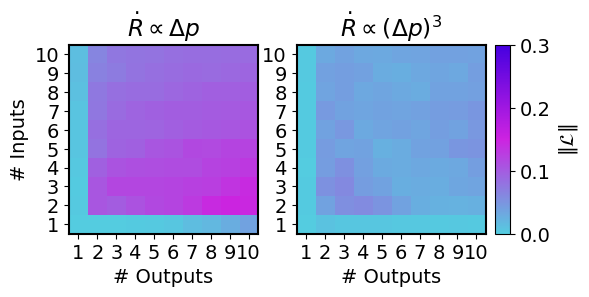

In [6]:
# Reload the module to reflect any changes made
importlib.reload(figure_plots)

figure_plots.loss_afo_in_out(loss_mat_lin, loss_mat_nonlin, Colorscheme)

## Comparison GD

In [7]:
load_folder_prelim = 'C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2025.3/regression_2_networks/'

t = np.load(load_folder_prelim + 't.npy')

R_mine_1in2out = np.load(load_folder_prelim + 'R_1in2out.npy')
R_mine_2in1out = np.load(load_folder_prelim + 'R_2in1out.npy')

loss_mine_1in2out = np.load(load_folder_prelim + 'loss_1in2out.npy')
loss_mine_2in1out = np.load(load_folder_prelim + 'loss_2in1out.npy')

cosine_sim_1in2out = np.load(load_folder_prelim + 'cosine_sim_1in2out.npy')
cosine_sim_2in1out = np.load(load_folder_prelim + 'cosine_sim_2in1out.npy')

load_folder_prelim = 'C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2025.4/regression_2_networks_GD/'

R_GD_1in2out = np.load(load_folder_prelim + 'R_1in2out.npy')
R_GD_2in1out = np.load(load_folder_prelim + 'R_2in1out.npy')

loss_GD_1in2out = np.load(load_folder_prelim + 'loss_1in2out.npy')
loss_GD_2in1out = np.load(load_folder_prelim + 'loss_2in1out.npy')

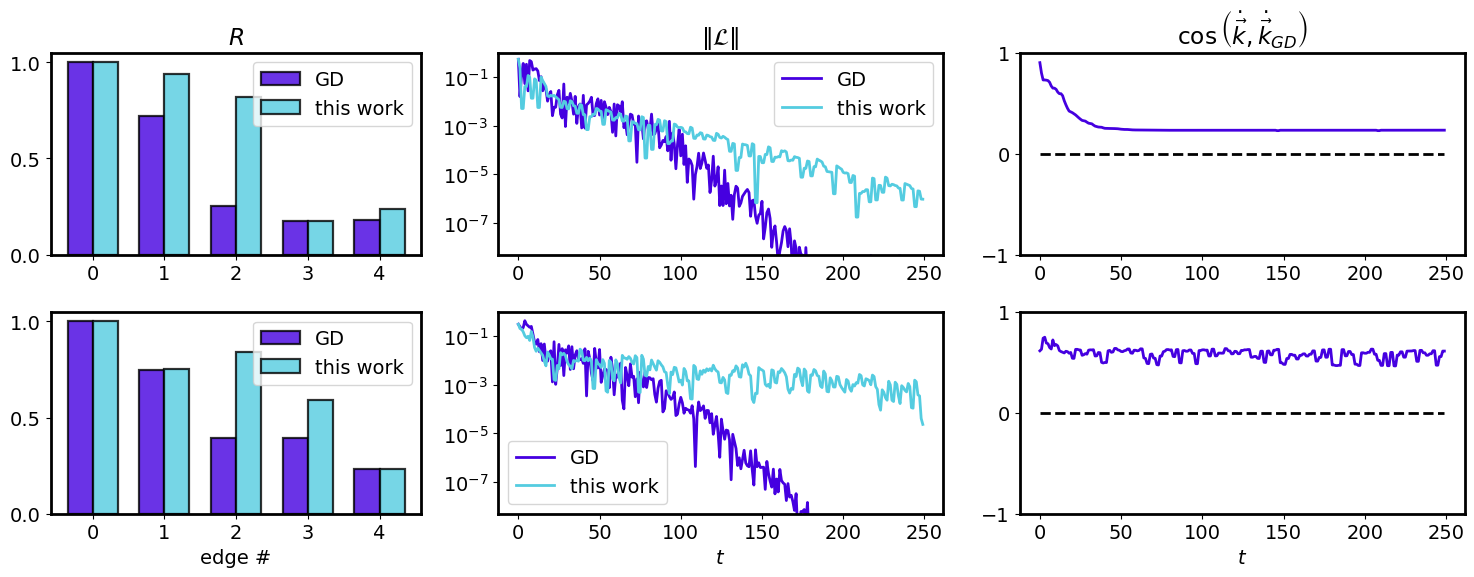

In [8]:
importlib.reload(figure_plots)
figure_plots.plot_comparison_GD(R_mine_1in2out, R_GD_1in2out, R_mine_2in1out, R_GD_2in1out, loss_mine_1in2out, loss_GD_1in2out,
                                loss_mine_2in1out, loss_GD_2in1out, cosine_sim_1in2out, cosine_sim_2in1out, Colorscheme)

## Accuracy classification only R_prop_deltap

In [9]:
t_final = np.load('C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2024.9/classification_after_bug_fix_1_material/t.npy')
t_for_accuracy = np.load('C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2024.9/classification_after_bug_fix_1_material/t_for_accuracy.npy')
accuracy_in_t = np.load('C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2024.9/classification_after_bug_fix_1_material/accuracy_in_t.npy')
dataset_shape = np.load('C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2024.9/classification_after_bug_fix_1_material/dataset_shape.npy')

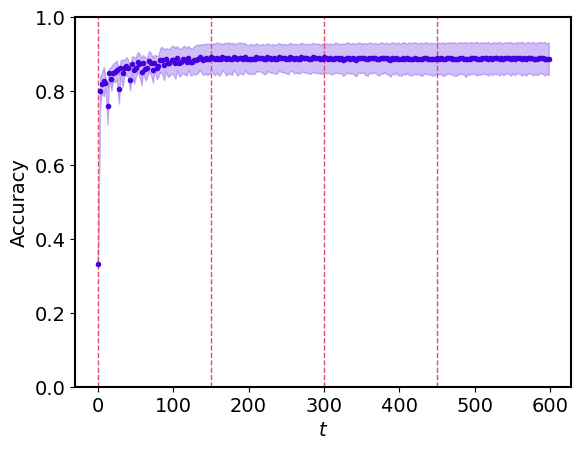

In [10]:
importlib.reload(figure_plots)
figure_plots.plot_accuracy_1_material(t_final, t_for_accuracy, accuracy_in_t, dataset_shape, Colorscheme,
                                       smooth=False, window_size=3)

## Accuracy classification all materials

In [11]:
load_folder_prelim = 'C:/Users/SMR_Admin/OneDrive - huji.ac.il/PhD/Network Simulation repo/figs and data/2024.9/accuracy_time8_after_bug_fix/'

t_final = np.load(load_folder_prelim + 't.npy')
dataset_shape = np.load(load_folder_prelim + 'dataset_shape.npy')
t_for_accuracy = np.load(load_folder_prelim + 't_for_accuracy.npy')

accuracy_in_t_R_propto_deltap = np.load(load_folder_prelim + 'R_propto_dpaccuracy_in_t.npy')
accuracy_in_t_deltaR_propto_deltap = np.load(load_folder_prelim + 'deltaR_propto_dpaccuracy_in_t.npy')
accuracy_in_t_deltaR_propto_Q = np.load(load_folder_prelim + 'deltaR_propto_Qaccuracy_in_t.npy')
accuracy_in_t_deltaR_propto_Power = np.load(load_folder_prelim + 'deltaR_propto_Poweraccuracy_in_t.npy')

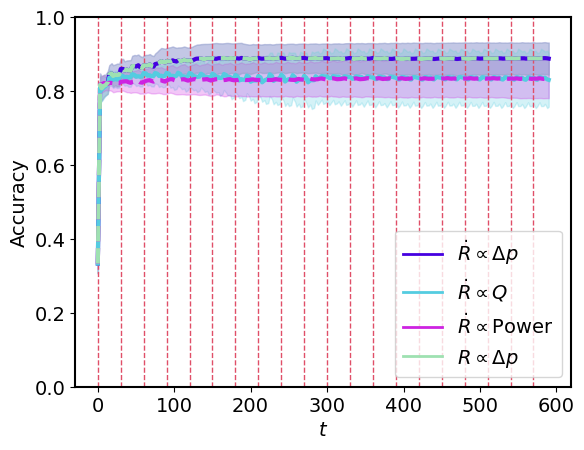

In [12]:
# Reload the module to reflect any changes made
importlib.reload(figure_plots)
importlib.reload(statistics)

figure_plots.plot_accuracy_4_materials(t_final, dataset_shape, t_for_accuracy, 
                                       accuracy_in_t_R_propto_deltap,\
                                       accuracy_in_t_deltaR_propto_deltap,\
                                       accuracy_in_t_deltaR_propto_Q,\
                                       accuracy_in_t_deltaR_propto_Power,
                                       Colorscheme,
                                       smooth=True, window_size=4)